# Classification Partielle Multi-Objectif avec JMetalPy
## OAFD – M2 MIAGE

Ce notebook implémente la classification partielle **multi-objectif** (représentation Michigan).  
Au lieu de maximiser la F1-mesure (un seul objectif), on optimise **simultanément** :
- **Objectif 1** : Confiance (Precision) à maximiser  
- **Objectif 2** : Sensibilité (Recall) à maximiser  

**Algorithmes testés :** NSGA-II et SPEA2  
**Jeux de données :** Yeast1 et PIMA Diabetes  
**Comparaison avec :** Random Forest, SVM, C4.5 (Scikit-Learn)

## 1. Imports et chargement des données

In [19]:
# ── Librairies standard ──
import random
import warnings
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
warnings.filterwarnings('ignore')
%matplotlib inline

# ── Scikit-Learn ──
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

# ── JMetalPy – Problème et opérateurs ──
from jmetal.core.problem import Problem
from jmetal.core.solution import FloatSolution
from jmetal.operator.mutation import PolynomialMutation
from jmetal.operator.crossover import SBXCrossover
from jmetal.util.termination_criterion import StoppingByEvaluations
from jmetal.util.solution import get_non_dominated_solutions

# ── JMetalPy – Algorithmes MO ──
from jmetal.algorithm.multiobjective.nsgaii import NSGAII
from jmetal.algorithm.multiobjective.spea2 import SPEA2

# ── JMetalPy – Indicateur de qualité ──
from jmetal.core.quality_indicator import HyperVolume

print('✓ Tous les imports OK')

✓ Tous les imports OK


In [20]:
# ── Chargement des données ──
df_pima = pd.read_csv('pima_diabetes.csv')
X_pima  = df_pima.drop('Outcome', axis=1).to_numpy()
y_pima  = df_pima['Outcome'].to_numpy()
features_pima = list(df_pima.columns[:-1])

df_yeast = pd.read_csv('yeast1.csv')
X_yeast  = df_yeast.drop('Output', axis=1).to_numpy()
y_yeast  = df_yeast['Output'].to_numpy()
features_yeast = list(df_yeast.columns[:-1])

print(f'PIMA   : {X_pima.shape}  | Positifs: {y_pima.sum()}  | Négatifs: {(y_pima==0).sum()}')
print(f'Yeast1 : {X_yeast.shape} | Positifs: {y_yeast.sum()} | Négatifs: {(y_yeast==0).sum()}')
print(f'\nAttributs PIMA   : {features_pima}')
print(f'Attributs Yeast1 : {features_yeast}')

PIMA   : (768, 8)  | Positifs: 268  | Négatifs: 500
Yeast1 : (1484, 8) | Positifs: 429 | Négatifs: 1055

Attributs PIMA   : ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
Attributs Yeast1 : ['Mcg', 'Gvh', 'Alm', 'Mit', 'Erl', 'Pox', 'Vac', 'Nuc']


## 2. Rappel des résultats Scikit-Learn (Étape 1)

Nous réexécutons les trois algorithmes de référence avec le **même protocole** :  
validation croisée 3-fold stratifiée, seed fixe = 42.  
On collecte **confiance** (precision) et **sensibilité** (recall) pour la comparaison avec les fronts Pareto.

In [21]:
def run_sklearn(X, y, model_fn, n_folds=3, seed=42):
    """Validation croisée N-fold – retourne precision et recall moyens."""
    skf = StratifiedKFold(n_splits=n_folds)
    all_prec, all_rec, all_f1 = [], [], []
    for train_idx, test_idx in skf.split(X, y):
        Xtr, Xte = X[train_idx], X[test_idx]
        ytr, yte = y[train_idx], y[test_idx]
        m = model_fn(seed)
        m.fit(Xtr, ytr)
        yp = m.predict(Xte)
        all_prec.append(precision_score(yte, yp, zero_division=0))
        all_rec.append(recall_score(yte, yp, zero_division=0))
        all_f1.append(f1_score(yte, yp, zero_division=0))
    return {
        'precision': np.mean(all_prec), 'recall': np.mean(all_rec), 'f1': np.mean(all_f1),
        'prec_std': np.std(all_prec),   'rec_std': np.std(all_rec),  'f1_std': np.std(all_f1)
    }

rf_fn  = lambda s: RandomForestClassifier(n_estimators=100, random_state=s)
svm_fn = lambda s: SVC(kernel='rbf', random_state=s)
c45_fn = lambda s: DecisionTreeClassifier(max_depth=4, random_state=s)

sklearn_results = {}
for ds_name, X, y in [('PIMA', X_pima, y_pima), ('Yeast1', X_yeast, y_yeast)]:
    sklearn_results[ds_name] = {}
    for algo_name, fn in [('RF', rf_fn), ('SVM', svm_fn), ('C4.5', c45_fn)]:
        r = run_sklearn(X, y, fn)
        sklearn_results[ds_name][algo_name] = r
        print(f'[{ds_name}] {algo_name:5s} | F1={r["f1"]:.3f}±{r["f1_std"]:.3f}'
              f' | Prec={r["precision"]:.3f}±{r["prec_std"]:.3f}'
              f' | Rec={r["recall"]:.3f}±{r["rec_std"]:.3f}')
    print()
print('✓ Baselines Scikit-Learn calculées')

[PIMA] RF    | F1=0.625±0.022 | Prec=0.692±0.054 | Rec=0.578±0.063
[PIMA] SVM   | F1=0.563±0.022 | Prec=0.721±0.021 | Rec=0.463±0.023
[PIMA] C4.5  | F1=0.555±0.028 | Prec=0.696±0.065 | Rec=0.474±0.071

[Yeast1] RF    | F1=0.537±0.038 | Prec=0.644±0.039 | Rec=0.464±0.051
[Yeast1] SVM   | F1=0.413±0.060 | Prec=0.707±0.100 | Rec=0.301±0.071
[Yeast1] C4.5  | F1=0.512±0.053 | Prec=0.577±0.063 | Rec=0.478±0.106

✓ Baselines Scikit-Learn calculées


## 3. Définition du Problème Multi-Objectif JMetalPy

### Représentation Michigan
Une solution = un vecteur de `2 × n_attributs` flottants.  
Chaque paire `(lower_i, upper_i)` définit les bornes d'un attribut :
- `lower_i > upper_i` → attribut **désactivé**  
- `lower_i ≤ upper_i` → attribut **activé**

### Deux objectifs (minimisation JMetalPy)
| Objectif | Formule | Sens |
|----------|---------|------|
| obj[0] | −Confiance (−Precision) | minimiser ↔ maximiser Precision |
| obj[1] | −Sensibilité (−Recall) | minimiser ↔ maximiser Recall |

Le **point de référence** pour l'Hypervolume est `[0.05, 0.05]`  
(légèrement au-dessus de 0 pour inclure les solutions avec score = 1.0).

In [22]:
class PartialClassifMO(Problem):
    """
    Classification Partielle – Problème multi-objectif (Michigan).
    Objectifs (à minimiser) : -Precision, -Recall.
    """

    def __init__(self, X: np.ndarray, y: np.ndarray):
        super().__init__()
        self.X = X
        self.y = y
        self.n_attributes = X.shape[1]
        self.pos_indices = np.where(y == 1)[0]
        self.neg_indices = np.where(y == 0)[0]

        self.lower_bound, self.upper_bound = [], []
        for i in range(self.n_attributes):
            cmin = float(np.min(X[:, i]))
            cmax = float(np.max(X[:, i]))
            if cmin == cmax:
                cmin -= 0.001; cmax += 0.001
            self.lower_bound += [cmin, cmin]
            self.upper_bound += [cmax + 1.0, cmax + 1.0]

        self.obj_directions = [self.MINIMIZE, self.MINIMIZE]
        self.obj_labels = ['-Precision', '-Recall']

    def number_of_variables(self):   return 2 * self.n_attributes 
    def number_of_objectives(self):  return 2
    def number_of_constraints(self): return 0

    def _decode(self, solution):
        vars_ = [float(v.real) if isinstance(v, complex) else float(v)
                 for v in solution.variables]
        bornes = [(vars_[i], vars_[i+1]) for i in range(0, len(vars_), 2)]
        activated = [(i, lo, hi) for i, (lo, hi) in enumerate(bornes) if lo <= hi]
        if not activated:
            return np.zeros(len(self.y), dtype=int)
        return np.array([
            1 if all(lo <= self.X[j, i] <= hi for i, lo, hi in activated) else 0
            for j in range(len(self.X))
        ])

    def evaluate(self, solution: FloatSolution) -> FloatSolution:
        y_pred = self._decode(solution)
        if y_pred.sum() == 0:
            solution.objectives[0] = 0.0   # Precision = 0
            solution.objectives[1] = 0.0   # Recall    = 0
        else:
            solution.objectives[0] = -float(precision_score(self.y, y_pred, zero_division=0))
            solution.objectives[1] = -float(recall_score(self.y, y_pred, zero_division=0))
        return solution

    def create_solution(self) -> FloatSolution:
        sol = FloatSolution(self.lower_bound, self.upper_bound,
                            self.number_of_objectives(), self.number_of_constraints())
        ind_pos = self.X[np.random.choice(self.pos_indices)]
        ind_neg = self.X[np.random.choice(self.neg_indices)]
        active  = set(np.random.choice(self.n_attributes, size=2, replace=False))
        vars_ = []
        for i in range(self.n_attributes):
            vp, vn = float(ind_pos[i]), float(ind_neg[i])
            if i in active:
                vars_ += [min(vp, vn), max(vp, vn)]
            else:
                vars_ += [vp + 1.0, vp]   # désactivé
        sol.variables = vars_
        return sol

    def name(self): return 'PartialClassifMO'


# ── Fonctions utilitaires ──────────────────────────────────────────────────
def predict(solution_vars, X):
    """Calcule y_pred à partir des variables d'une solution."""
    vars_ = [float(v.real) if isinstance(v, complex) else float(v) for v in solution_vars]
    bornes = [(vars_[i], vars_[i+1]) for i in range(0, len(vars_), 2)]
    activated = [(i, lo, hi) for i, (lo, hi) in enumerate(bornes) if lo <= hi]
    if not activated:
        return np.zeros(len(X), dtype=int)
    return np.array([
        1 if all(lo <= X[j, i] <= hi for i, lo, hi in activated) else 0
        for j in range(len(X))
    ])

def decode_rule(solution_vars, feature_names):
    """Affiche la règle lisible."""
    bornes = [(solution_vars[i], solution_vars[i+1]) for i in range(0, len(solution_vars), 2)]
    parts = [
        f'{feature_names[i]} ∈ [{lo:.3f}, {hi:.3f}]'
        for i, (lo, hi) in enumerate(bornes) if lo <= hi
    ]
    rule = 'SI ' + ' ET '.join(parts) + ' → classe positive' if parts else 'Règle vide'
    print('Règle :', rule)
    return rule

def compute_hv(solutions, ref_point=None):
    """Hypervolume du front Pareto (espace minimisation)."""
    if not solutions:
        return 0.0
    front = np.array([s.objectives for s in solutions])
    if ref_point is None:
        ref_point = [0.05, 0.05]
    hv_calc = HyperVolume(ref_point)
    return hv_calc.compute(front)

def get_pareto_front(solutions):
    """Extrait les solutions non-dominées."""
    return get_non_dominated_solutions(solutions)

print('✓ Classe PartialClassifMO et fonctions utilitaires définies')

✓ Classe PartialClassifMO et fonctions utilitaires définies


## 4. Paramètres expérimentaux

### 4.1 Paramètres fixes

Les paramètres suivants sont **identiques** pour les deux algorithmes et toutes les configurations :

| Paramètre | Valeur | Justification |
|-----------|--------|---------------|
| Prob. croisement | 0.9 | Valeur standard recommandée pour SBX |
| Index croisement | 20 | Distribution concentrée autour des parents |
| Prob. mutation | 1/n_vars | Règle du pouce : une variable mutée par individu |
| Index mutation | 20 | Perturbations modérées |
| Max évaluations | **déterminé section 4.3** | Fixé automatiquement par étude de convergence |
| Validation croisée | — | Pas utilisée (train/test split stratifié 70/30) |
| N_RUNS | 20 | Minimum requis pour significativité statistique |

### 4.2 Choix des tailles de population

Trois tailles sont testées pour isoler l'effet de ce seul paramètre :

| Taille | Motivation |
|--------|-----------|
| **20** | Population petite – convergence rapide mais diversité faible |
| **50** | Taille intermédiaire – bon équilibre exploration/exploitation |
| **100** | Grande population – meilleure couverture du front Pareto, coût accru |

Ces tailles couvrent un ordre de grandeur (×5) permettant d'observer l'impact sur la qualité du front Pareto.

In [23]:
# ── Paramètres fixes ────────────────────────────────────────────────────────
CROSSOVER_PROB  = 0.9
CROSSOVER_INDEX = 20.0
MUTATION_INDEX  = 20.0
MAX_EVALUATIONS = 500   # déterminé en section 4.3
N_RUNS          = 7
N_FOLDS         = 3
REF_POINT       = [0.05, 0.05]
POP_SIZES       = [20, 50, 100]

# ── Validation croisée 3-fold stratifiée ─────────────────────────────────────
# Même protocole que run_sklearn() → comparaison fair avec RF, SVM, C4.5
# Pour chaque fold : AG entraîné sur fold_train, évalué sur fold_test
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
folds_pima  = list(skf.split(X_pima,  y_pima))
folds_yeast = list(skf.split(X_yeast, y_yeast))

# Fold 0 utilisé pour l'étude de convergence uniquement
X_conv_pima, y_conv_pima = X_pima[folds_pima[0][0]],   y_pima[folds_pima[0][0]]

print(f'Validation croisée {N_FOLDS}-fold stratifiée (random_state=42)')
print(f'PIMA   : {len(folds_pima[0][0])} train / {len(folds_pima[0][1])} test par fold')
print(f'Yeast1 : {len(folds_yeast[0][0])} train / {len(folds_yeast[0][1])} test par fold')
print(f'\nTotal runs AG : {N_FOLDS} folds × {N_RUNS} runs × {len(POP_SIZES)} pop × 2 algos × 2 datasets')
print(f'             = {N_FOLDS * N_RUNS * len(POP_SIZES) * 2 * 2} runs')

Validation croisée 3-fold stratifiée (random_state=42)
PIMA   : 512 train / 256 test par fold
Yeast1 : 989 train / 495 test par fold

Total runs AG : 3 folds × 7 runs × 3 pop × 2 algos × 2 datasets
             = 252 runs


## 4.3 Étude de convergence – Détermination du nombre d'évaluations optimal

Avant de lancer les 20 runs, on détermine le **nombre d'évaluations nécessaire** pour que les algorithmes convergent.

**Protocole :**
- 1 seul run (seed = 42) par budget testé
- Population fixée à **50** (taille intermédiaire)
- Budgets testés : 100, 250, 500, 1000, 2500, 5000, 7500, 10 000
- Métrique : **Hypervolume** du front Pareto obtenu
- Les 2 algorithmes (NSGA-II et SPEA2) sont testés sur les 2 datasets

👉 On choisit le budget à partir duquel la courbe **se stabilise (plateau)** : gain marginal < 1%.

[2026-03-30 02:17:28,946] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-30 02:17:28,954] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-30 02:17:29,101] [jmetal.core.algorithm] [DEBUG] Initializing progress...


Convergence : NSGA-II sur PIMA fold 0 (1 run, seed=42)



[2026-03-30 02:17:29,102] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-30 02:17:29,253] [jmetal.core.algorithm] [DEBUG] Finished!
[2026-03-30 02:17:29,254] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-30 02:17:29,257] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-30 02:17:29,411] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-30 02:17:29,412] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met


  budget=   100 -> HV=0.4414


[2026-03-30 02:17:29,993] [jmetal.core.algorithm] [DEBUG] Finished!
[2026-03-30 02:17:29,994] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-30 02:17:29,998] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-30 02:17:30,150] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-30 02:17:30,151] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met


...

  budget=  5000 -> HV=0.8151


[2026-03-30 02:18:00,571] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-30 02:18:00,574] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-30 02:18:23,749] [jmetal.core.algorithm] [DEBUG] Finished!
[2026-03-30 02:18:23,752] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-30 02:18:23,756] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-30 02:18:23,916] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-30 02:18:23,918] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met


  budget=  7500 -> HV=0.8183


[2026-03-30 02:18:54,237] [jmetal.core.algorithm] [DEBUG] Finished!


  budget= 10000 -> HV=0.8188

Termine en 85.3s | Plateau suggere : 7500


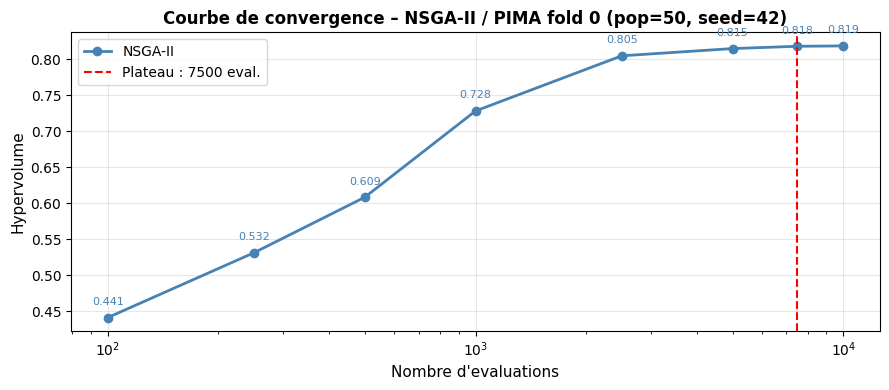

In [24]:
EVAL_BUDGETS = [100, 250, 500, 1000, 2500, 5000, 7500, 10_000]
CONV_POP     = 50
CONV_SEED    = 42

def run_convergence_study(X_train, y_train, algo_name,
                           budgets=EVAL_BUDGETS, pop_size=CONV_POP, seed=CONV_SEED):
    """1 run par budget – retourne les HV obtenus."""
    hvs = []
    for budget in budgets:
        random.seed(seed); np.random.seed(seed)
        problem   = PartialClassifMO(X_train, y_train)
        n_vars    = 2 * X_train.shape[1]
        mutation  = PolynomialMutation(probability=1.0/n_vars, distribution_index=MUTATION_INDEX)
        crossover = SBXCrossover(probability=CROSSOVER_PROB, distribution_index=CROSSOVER_INDEX)
        if algo_name == 'NSGA-II':
            algo = NSGAII(problem=problem, population_size=pop_size,
                          offspring_population_size=pop_size, mutation=mutation,
                          crossover=crossover, termination_criterion=StoppingByEvaluations(budget))
        else:
            algo = SPEA2(problem=problem, population_size=pop_size,
                         offspring_population_size=pop_size, mutation=mutation,
                         crossover=crossover, termination_criterion=StoppingByEvaluations(budget))
        algo.run()
        hvs.append(compute_hv(get_pareto_front(algo.get_result()), REF_POINT))
        print(f'  budget={budget:6d} -> HV={hvs[-1]:.4f}')
    return hvs

def find_plateau(budgets, hvs, threshold=0.01):
    for i in range(1, len(hvs)):
        if hvs[i-1] == 0: continue
        if (hvs[i] - hvs[i-1]) / max(hvs[i-1], 1e-9) < threshold:
            return budgets[i]
    return budgets[-1]

# ── 1 run NSGA-II sur fold 0 de PIMA ─────────────────────────────────────────
print('Convergence : NSGA-II sur PIMA fold 0 (1 run, seed=42)\n')
t0 = time.time()
hvs_conv = run_convergence_study(X_conv_pima, y_conv_pima, 'NSGA-II')
plateau_retenu = find_plateau(EVAL_BUDGETS, hvs_conv)
print(f'\nTermine en {time.time()-t0:.1f}s | Plateau suggere : {plateau_retenu}')

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(EVAL_BUDGETS, hvs_conv, marker='o', linewidth=2, color='steelblue', label='NSGA-II')
for x, y in zip(EVAL_BUDGETS, hvs_conv):
    ax.annotate(f'{y:.3f}', (x, y), textcoords='offset points',
                xytext=(0, 9), ha='center', fontsize=8, color='steelblue')
ax.axvline(plateau_retenu, color='red', linestyle='--', linewidth=1.5,
           label=f'Plateau : {plateau_retenu} eval.')
ax.set_title('Courbe de convergence – NSGA-II / PIMA fold 0 (pop=50, seed=42)',
             fontsize=12, fontweight='bold')
ax.set_xlabel("Nombre d'evaluations", fontsize=11)
ax.set_ylabel('Hypervolume', fontsize=11)
ax.set_xscale('log')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('convergence_study.png', dpi=150, bbox_inches='tight')
plt.show()

### Choix manuel du nombre d'évaluations

Regarde la courbe ci-dessus et **choisis toi-même** le budget qui te convient :
- La ligne rouge indique le plateau détecté automatiquement
- Tu peux prendre une valeur **plus basse** si tu veux aller plus vite
- Tu peux prendre une valeur **plus haute** si tu veux plus de qualité

👇 **Modifie uniquement la ligne `MAX_EVALUATIONS = ...` ci-dessous**

In [25]:
# ╔══════════════════════════════════════════════════════╗
# ║  MODIFIE CETTE VALEUR selon la courbe de convergence ║
# ╚══════════════════════════════════════════════════════╝

MAX_EVALUATIONS = 500   # ← change ce nombre

# ─────────────────────────────────────────────────────────
print(f'MAX_EVALUATIONS choisi : {MAX_EVALUATIONS}')
print(f'Ce budget sera utilise pour tous les 20 runs suivants.')

MAX_EVALUATIONS choisi : 500
Ce budget sera utilise pour tous les 20 runs suivants.


## 5. Fonction d'exécution des algorithmes MO

In [26]:
def run_mo_algorithm(algo_name, X_train, y_train, pop_size,
                     max_evaluations=MAX_EVALUATIONS, seed=42):
    """Lance NSGA-II ou SPEA2 et retourne la population finale."""
    random.seed(seed); np.random.seed(seed)
    problem  = PartialClassifMO(X_train, y_train)
    n_vars   = 2 * X_train.shape[1]
    mutation  = PolynomialMutation(probability=1.0/n_vars, distribution_index=MUTATION_INDEX)
    crossover = SBXCrossover(probability=CROSSOVER_PROB, distribution_index=CROSSOVER_INDEX)
    criterion = StoppingByEvaluations(max_evaluations=max_evaluations)
    if algo_name == 'NSGA-II':
        algo = NSGAII(problem=problem, population_size=pop_size,
                      offspring_population_size=pop_size,
                      mutation=mutation, crossover=crossover, termination_criterion=criterion)
    elif algo_name == 'SPEA2':
        algo = SPEA2(problem=problem, population_size=pop_size,
                     offspring_population_size=pop_size,
                     mutation=mutation, crossover=crossover, termination_criterion=criterion)
    else:
        raise ValueError(f'Algorithme inconnu : {algo_name}')
    algo.run()
    return algo.get_result()


def best_f1_solution(front, X_train, y_train):
    """Sélectionne la solution avec le meilleur F1 sur le training."""
    best_f1, best_sol = -1, None
    for s in front:
        yp = predict(s.variables, X_train)
        f1 = f1_score(y_train, yp, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1; best_sol = s
    return best_sol, best_f1


def run_experiments(algo_name, X, y, folds, pop_sizes=POP_SIZES, n_runs=N_RUNS):
    """
    Validation croisée N_FOLDS × N_RUNS — même protocole que run_sklearn().

    Pour chaque pop_size × fold × run :
      - Entraîne l'AG sur fold_train
      - Extrait le front Pareto
      - Calcule l'HV (pour boxplots)
      - Sélectionne la meilleure solution (best F1 sur train)
      - Évalue sur fold_test → precision, recall, F1

    Retourne :
      {pop_size: {
          'hv'    : [...N_FOLDS × N_RUNS valeurs...],
          'fronts': [{nd, X_tr, y_tr, X_te, y_te, fold}, ...],
          'precision', 'recall', 'f1',   ← moyennes CV
          'prec_std', 'rec_std', 'f1_std'
      }}
    """
    results = {}
    for pop_size in pop_sizes:
        print(f'  {algo_name} | pop={pop_size:3d}', end='', flush=True)
        hvs, fronts = [], []
        all_prec, all_rec, all_f1 = [], [], []

        for fold_idx, (train_idx, test_idx) in enumerate(folds):
            X_tr, y_tr = X[train_idx], y[train_idx]
            X_te, y_te = X[test_idx],  y[test_idx]

            for run in range(n_runs):
                seed = fold_idx * 10_000 + run * 100 + 42
                solutions  = run_mo_algorithm(algo_name, X_tr, y_tr, pop_size, seed=seed)
                nd         = get_pareto_front(solutions)
                hv         = compute_hv(nd, REF_POINT)
                best_sol, _= best_f1_solution(nd, X_tr, y_tr)

                yp_te = predict(best_sol.variables, X_te)
                all_prec.append(precision_score(y_te, yp_te, zero_division=0))
                all_rec.append(recall_score(y_te, yp_te, zero_division=0))
                all_f1.append(f1_score(y_te, yp_te, zero_division=0))

                hvs.append(hv)
                fronts.append({'nd': nd, 'X_tr': X_tr, 'y_tr': y_tr,
                               'X_te': X_te, 'y_te': y_te,
                               'fold': fold_idx, 'best_sol': best_sol})
                print('.', end='', flush=True)

        results[pop_size] = {
            'hv': hvs, 'fronts': fronts,
            'precision': np.mean(all_prec), 'recall': np.mean(all_rec), 'f1': np.mean(all_f1),
            'prec_std':  np.std(all_prec),  'rec_std': np.std(all_rec),  'f1_std': np.std(all_f1)
        }
        print(f'  HV={np.mean(hvs):.4f}±{np.std(hvs):.4f}'
              f' | F1_test={np.mean(all_f1):.3f}±{np.std(all_f1):.3f}')
    return results

print('✓ run_mo_algorithm, best_f1_solution, run_experiments définis')

✓ run_mo_algorithm, best_f1_solution, run_experiments définis


## 6. Exécution NSGA-II

In [27]:
print('='*60)
print('NSGA-II – PIMA  (3 folds × 20 runs × 3 pop)')
print('='*60)
t0 = time.time()
nsgaii_pima = run_experiments('NSGA-II', X_pima, y_pima, folds_pima)
print(f'\nTemps total : {time.time()-t0:.1f}s')

NSGA-II – PIMA  (3 folds × 20 runs × 3 pop)
  NSGA-II | pop= 20

[2026-03-30 02:18:55,026] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-30 02:18:55,030] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-30 02:18:55,103] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-30 02:18:55,104] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-30 02:18:56,538] [jmetal.core.algorithm] [DEBUG] Finished!


.

[2026-03-30 02:18:56,581] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-30 02:18:56,584] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-30 02:18:56,655] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-30 02:18:56,657] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-30 02:18:58,253] [jmetal.core.algorithm] [DEBUG] Finished!


.

...

.

[2026-03-30 02:20:27,233] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-30 02:20:27,238] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-30 02:20:27,750] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-30 02:20:27,752] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-30 02:20:29,421] [jmetal.core.algorithm] [DEBUG] Finished!


.

[2026-03-30 02:20:29,452] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-30 02:20:29,458] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-30 02:20:29,800] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-30 02:20:29,801] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-30 02:20:30,907] [jmetal.core.algorithm] [DEBUG] Finished!


.  HV=0.5954±0.0421 | F1_test=0.550±0.036

Temps total : 95.9s


In [28]:
print('='*60)
print('NSGA-II – Yeast1  (3 folds × 20 runs × 3 pop)')
print('='*60)
t0 = time.time()
nsgaii_yeast = run_experiments('NSGA-II', X_yeast, y_yeast, folds_yeast)
print(f'\nTemps total : {time.time()-t0:.1f}s')

NSGA-II – Yeast1  (3 folds × 20 runs × 3 pop)
  NSGA-II | pop= 20

[2026-03-30 02:20:30,944] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-30 02:20:30,947] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-30 02:20:31,028] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-30 02:20:31,029] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-30 02:20:32,689] [jmetal.core.algorithm] [DEBUG] Finished!


.

[2026-03-30 02:20:32,731] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-30 02:20:32,732] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-30 02:20:32,799] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-30 02:20:32,800] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-30 02:20:34,522] [jmetal.core.algorithm] [DEBUG] Finished!


.

...

.

[2026-03-30 02:22:41,323] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-30 02:22:41,342] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-30 02:22:42,352] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-30 02:22:42,353] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-30 02:22:47,183] [jmetal.core.algorithm] [DEBUG] Finished!


.

[2026-03-30 02:22:47,363] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-30 02:22:47,386] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-30 02:22:49,038] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-30 02:22:49,041] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-30 02:22:53,487] [jmetal.core.algorithm] [DEBUG] Finished!


.  HV=0.5683±0.0296 | F1_test=0.524±0.022

Temps total : 142.8s


## 7. Exécution SPEA2

In [29]:
print('='*60)
print('SPEA2 – PIMA  (3 folds × 20 runs × 3 pop)')
print('='*60)
t0 = time.time()
spea2_pima = run_experiments('SPEA2', X_pima, y_pima, folds_pima)
print(f'\nTemps total : {time.time()-t0:.1f}s')

SPEA2 – PIMA  (3 folds × 20 runs × 3 pop)
  SPEA2 | pop= 20

[2026-03-30 02:22:53,753] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-30 02:22:53,762] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-30 02:22:54,057] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-30 02:22:54,061] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-30 02:23:01,191] [jmetal.core.algorithm] [DEBUG] Finished!


.

[2026-03-30 02:23:01,332] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-30 02:23:01,340] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-30 02:23:01,638] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-30 02:23:01,639] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-30 02:23:08,796] [jmetal.core.algorithm] [DEBUG] Finished!


.

...

.

[2026-03-30 02:25:34,204] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-30 02:25:34,209] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-30 02:25:34,631] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-30 02:25:34,632] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-30 02:25:36,541] [jmetal.core.algorithm] [DEBUG] Finished!


.

[2026-03-30 02:25:36,569] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-30 02:25:36,574] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-30 02:25:36,878] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-30 02:25:36,878] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-30 02:25:38,433] [jmetal.core.algorithm] [DEBUG] Finished!


.  HV=0.6149±0.0444 | F1_test=0.559±0.035

Temps total : 164.7s


In [30]:
print('='*60)
print('SPEA2 – Yeast1  (3 folds × 20 runs × 3 pop)')
print('='*60)
t0 = time.time()
spea2_yeast = run_experiments('SPEA2', X_yeast, y_yeast, folds_yeast)
print(f'\nTemps total : {time.time()-t0:.1f}s')

SPEA2 – Yeast1  (3 folds × 20 runs × 3 pop)
  SPEA2 | pop= 20

[2026-03-30 02:25:38,471] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-30 02:25:38,474] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-30 02:25:38,549] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-30 02:25:38,550] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-30 02:25:40,961] [jmetal.core.algorithm] [DEBUG] Finished!


.

[2026-03-30 02:25:41,006] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-30 02:25:41,008] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-30 02:25:41,084] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-30 02:25:41,085] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-30 02:25:43,819] [jmetal.core.algorithm] [DEBUG] Finished!


.

...

.

[2026-03-30 02:31:31,617] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-30 02:31:31,618] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-30 02:31:32,076] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-30 02:31:32,077] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-30 02:31:34,178] [jmetal.core.algorithm] [DEBUG] Finished!


.

[2026-03-30 02:31:34,253] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-30 02:31:34,268] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-30 02:31:34,751] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-30 02:31:34,751] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-30 02:31:36,498] [jmetal.core.algorithm] [DEBUG] Finished!


.  HV=0.5660±0.0285 | F1_test=0.511±0.020

Temps total : 358.1s


## 8. Boxplots de l'Hypervolume par taille de population

Ces boxplots permettent de comparer visuellement la qualité des fronts Pareto  
obtenus selon la taille de population, pour chaque algorithme et chaque jeu de données.

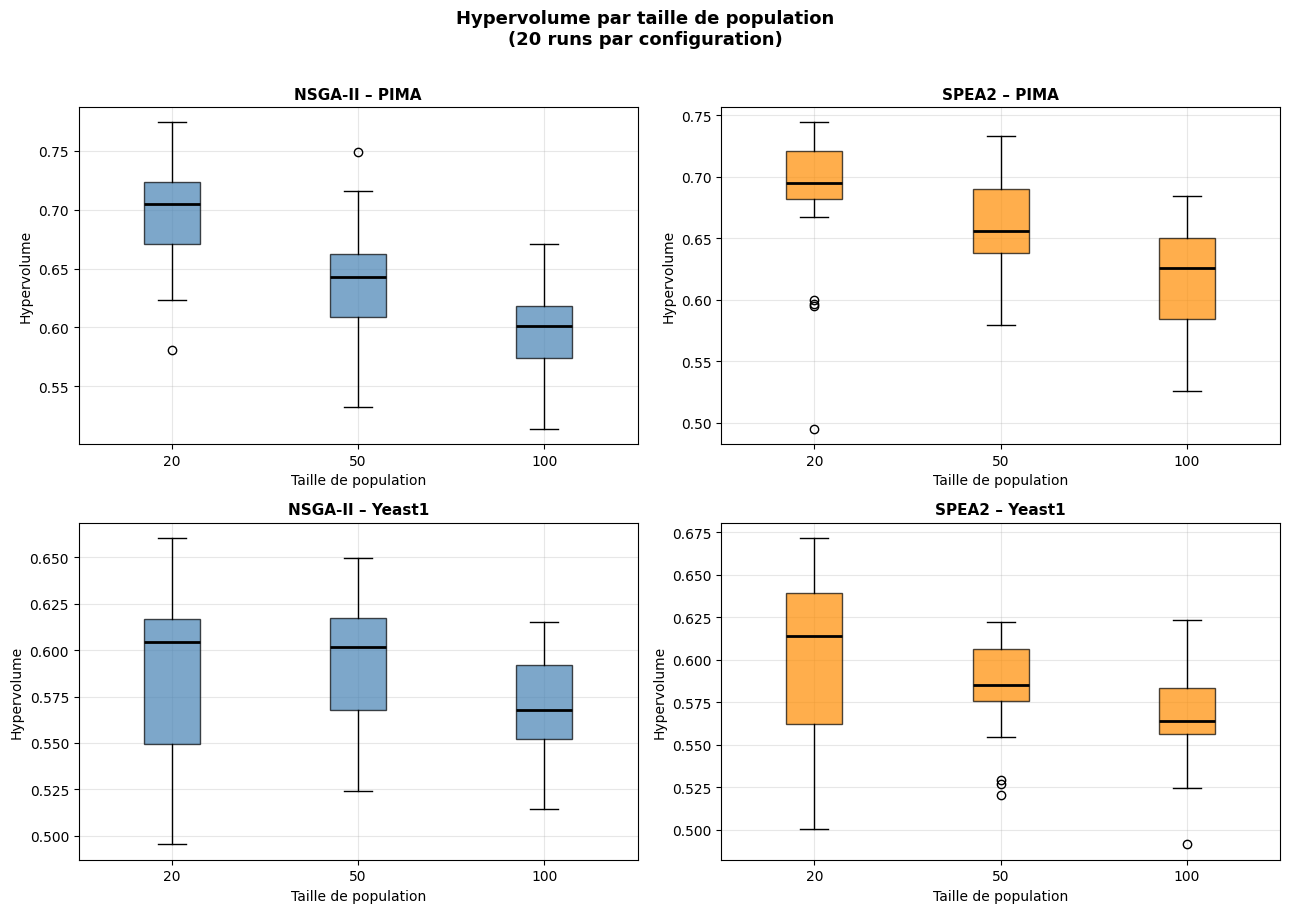

✓ Boxplots sauvegardés


In [31]:
def plot_hv_boxplots(results_dict, algo_name, dataset_name, ax, color='steelblue'):
    data   = [results_dict[p]['hv'] for p in POP_SIZES]
    labels = [str(p) for p in POP_SIZES]
    bp = ax.boxplot(data, labels=labels, patch_artist=True,
                    medianprops=dict(color='black', linewidth=2))
    for patch in bp['boxes']:
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(f'{algo_name} – {dataset_name}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Taille de population', fontsize=10)
    ax.set_ylabel('Hypervolume', fontsize=10)
    ax.grid(True, alpha=0.3)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

plot_hv_boxplots(nsgaii_pima,  'NSGA-II', 'PIMA',   axes[0, 0], color='steelblue')
plot_hv_boxplots(spea2_pima,   'SPEA2',   'PIMA',   axes[0, 1], color='darkorange')
plot_hv_boxplots(nsgaii_yeast, 'NSGA-II', 'Yeast1', axes[1, 0], color='steelblue')
plot_hv_boxplots(spea2_yeast,  'SPEA2',   'Yeast1', axes[1, 1], color='darkorange')

plt.suptitle('Hypervolume par taille de population\n(20 runs par configuration)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('boxplots_hv.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Boxplots sauvegardés')

## 9. Sélection du meilleur front Pareto et comparaison avec Scikit-Learn

**Protocole :**
1. Pour chaque algorithme, sélectionner le run avec le **meilleur Hypervolume sur le training**.
2. Superposer les points Scikit-Learn (precision, recall) sur le graphe des fronts Pareto.
3. Choisir la **meilleure solution** de chaque front = celle avec le meilleur F1 sur le training.

In [32]:
def get_best_run(results_dict):
    """
    Retourne le front Pareto du run avec le meilleur HV,
    ainsi que les infos de son fold (X_tr, y_tr, X_te, y_te).
    """
    best_hv, best_pop, best_front_info = -1, None, None
    for pop_size, res in results_dict.items():
        idx = int(np.argmax(res['hv']))
        if res['hv'][idx] > best_hv:
            best_hv          = res['hv'][idx]
            best_pop         = pop_size
            best_front_info  = res['fronts'][idx]
    return best_pop, best_front_info['nd'], best_hv, best_front_info


def front_to_prec_rec(front):
    return [-s.objectives[0] for s in front], [-s.objectives[1] for s in front]


# ── Sélection du meilleur run pour chaque algo × dataset ────────────────────
best = {}
for ds_name, nsgaii_res, spea2_res in [
        ('PIMA',   nsgaii_pima,  spea2_pima),
        ('Yeast1', nsgaii_yeast, spea2_yeast)]:

    best[ds_name] = {}
    for algo_name, res in [('NSGA-II', nsgaii_res), ('SPEA2', spea2_res)]:
        pop, front, hv, info = get_best_run(res)
        best_sol = info['best_sol']   # déjà calculé pendant run_experiments
        best[ds_name][algo_name] = {
            'pop': pop, 'front': front, 'hv': hv,
            'best_sol': best_sol, 'fold_info': info
        }
        print(f'[{ds_name}] {algo_name} → pop={pop}, HV={hv:.4f}, '
              f'fold={info["fold"]}')
print()

[PIMA] NSGA-II → pop=20, HV=0.7742, fold=2
[PIMA] SPEA2 → pop=20, HV=0.7440, fold=2
[Yeast1] NSGA-II → pop=20, HV=0.6604, fold=2
[Yeast1] SPEA2 → pop=20, HV=0.6715, fold=0



### 9.1 Visualisation des fronts Pareto

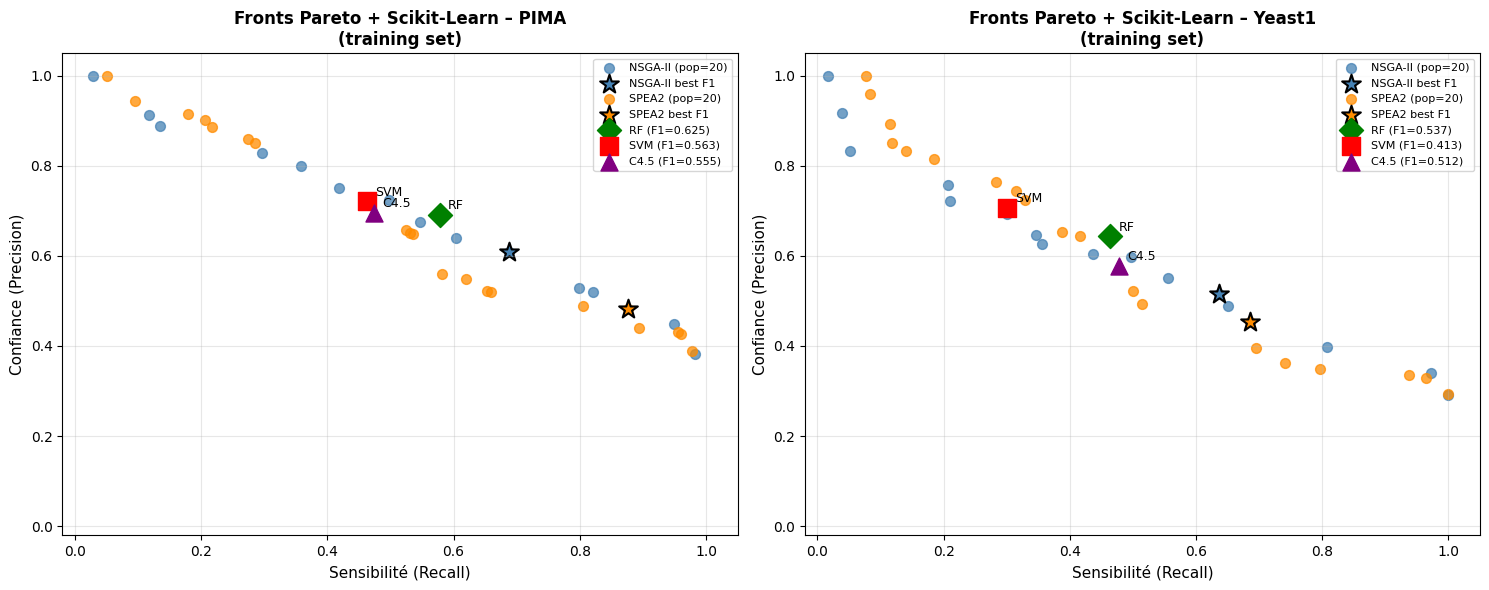

✓ Fronts Pareto sauvegardés


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

colors_algo = {'NSGA-II': 'steelblue', 'SPEA2': 'darkorange'}
markers_sk  = {'RF': 'D', 'SVM': 's', 'C4.5': '^'}
colors_sk   = {'RF': 'green', 'SVM': 'red', 'C4.5': 'purple'}
    
for ax, ds_name in [
        (axes[0], 'PIMA'),
        (axes[1], 'Yeast1')]:
    X_tr = best[ds_name]['NSGA-II']['fold_info']['X_tr']
    y_tr = best[ds_name]['NSGA-II']['fold_info']['y_tr']

    # ── Fronts Pareto des AG MO ─────────────────────────────────────────────
    for algo_name in ['NSGA-II', 'SPEA2']:
        front = best[ds_name][algo_name]['front']
        prec, rec = front_to_prec_rec(front)
        ax.scatter(rec, prec, color=colors_algo[algo_name], alpha=0.75, s=50,
                   label=f'{algo_name} (pop={best[ds_name][algo_name]["pop"]})')

        # Marquer la meilleure solution (F1 max)
        sol = best[ds_name][algo_name]['best_sol']
        bp = -sol.objectives[0]; br = -sol.objectives[1]
        ax.scatter(br, bp, color=colors_algo[algo_name], s=200, marker='*',
                   edgecolors='black', linewidths=1.5,
                   label=f'{algo_name} best F1')

    # ── Points Scikit-Learn (training) ──────────────────────────────────────
    for sk_name, res in sklearn_results[ds_name].items():
        ax.scatter(res['recall'], res['precision'],
                   marker=markers_sk[sk_name], color=colors_sk[sk_name],
                   s=150, zorder=5,
                   label=f'{sk_name} (F1={res["f1"]:.3f})')
        ax.annotate(sk_name,
                    (res['recall'], res['precision']),
                    textcoords='offset points', xytext=(6, 4), fontsize=9)

    ax.set_xlabel('Sensibilité (Recall)', fontsize=11)
    ax.set_ylabel('Confiance (Precision)', fontsize=11)
    ax.set_title(f'Fronts Pareto + Scikit-Learn – {ds_name}\n(training set)',
                 fontsize=12, fontweight='bold')
    ax.set_xlim(-0.02, 1.05)
    ax.set_ylim(-0.02, 1.05)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pareto_fronts_sklearn.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Fronts Pareto sauvegardés')

## 10. Évaluation sur le jeu de test

On évalue les meilleures solutions sélectionnées à l'étape précédente  
(meilleur F1 sur le training) sur le **jeu de test** pour mesurer la généralisation.

In [35]:
test_results = {}

for ds_name in ['PIMA', 'Yeast1']:
    print(f'\n{"="*55}')
    print(f'Dataset : {ds_name}')
    print(f'{"="*55}')
    test_results[ds_name] = {}

    for algo_name in ['NSGA-II', 'SPEA2']:
        info     = best[ds_name][algo_name]['fold_info']
        best_sol = best[ds_name][algo_name]['best_sol']
        X_tr, y_tr = info['X_tr'], info['y_tr']
        X_te, y_te = info['X_te'], info['y_te']

        # Évaluation training (fold correspondant)
        yp_tr = predict(best_sol.variables, X_tr)
        pr_tr = precision_score(y_tr, yp_tr, zero_division=0)
        rc_tr = recall_score(y_tr, yp_tr, zero_division=0)
        f1_tr = f1_score(y_tr, yp_tr, zero_division=0)

        # Évaluation test (fold correspondant)
        yp_te = predict(best_sol.variables, X_te)
        pr_te = precision_score(y_te, yp_te, zero_division=0)
        rc_te = recall_score(y_te, yp_te, zero_division=0)
        f1_te = f1_score(y_te, yp_te, zero_division=0)

        test_results[ds_name][algo_name] = {
            'precision_test': pr_te, 'recall_test': rc_te, 'f1_test': f1_te,
            'hv': best[ds_name][algo_name]['hv'],
            'pop': best[ds_name][algo_name]['pop'],
        }
        pop = best[ds_name][algo_name]['pop']
        print(f'\n  ── {algo_name} (pop={pop}, fold={info["fold"]}) ──')
        print(f'    Train  | Prec={pr_tr:.3f} | Rec={rc_tr:.3f} | F1={f1_tr:.3f}')
        print(f'    Test   | Prec={pr_te:.3f} | Rec={rc_te:.3f} | F1={f1_te:.3f}')
        print(f'    HV = {best[ds_name][algo_name]["hv"]:.4f}')
        print(f'    Règle :')
        feat = features_pima if ds_name == 'PIMA' else features_yeast
        decode_rule(best_sol.variables, feat)


Dataset : PIMA

  ── NSGA-II (pop=20, fold=2) ──
    Train  | Prec=0.609 | Rec=0.687 | F1=0.646
    Test   | Prec=0.542 | Rec=0.730 | F1=0.622
    HV = 0.7742
    Règle :
Règle : SI Glucose ∈ [123.379, 199.935] → classe positive

  ── SPEA2 (pop=20, fold=2) ──
    Train  | Prec=0.483 | Rec=0.877 | F1=0.623
    Test   | Prec=0.441 | Rec=0.888 | F1=0.590
    HV = 0.7440
    Règle :
Règle : SI Glucose ∈ [105.713, 199.521] → classe positive

Dataset : Yeast1

  ── NSGA-II (pop=20, fold=2) ──
    Train  | Prec=0.516 | Rec=0.636 | F1=0.570
    Test   | Prec=0.508 | Rec=0.657 | F1=0.573
    HV = 0.6604
    Règle :
Règle : SI Alm ∈ [0.413, 0.642] ET Pox ∈ [0.000, 0.000] ET Nuc ∈ [0.226, 0.715] → classe positive

  ── SPEA2 (pop=20, fold=0) ──
    Train  | Prec=0.453 | Rec=0.685 | F1=0.545
    Test   | Prec=0.432 | Rec=0.664 | F1=0.523
    HV = 0.6715
    Règle :
Règle : SI Nuc ∈ [0.229, 0.729] → classe positive


## 11. Tableau comparatif final

In [36]:
def fmt(v): return f'{v:.3f}'

rows = []
for ds_name, nsgaii_res, spea2_res in [
        ('PIMA',   nsgaii_pima,  spea2_pima),
        ('Yeast1', nsgaii_yeast, spea2_yeast)]:

    # ── Scikit-Learn (CV 3-fold via run_sklearn) ─────────────────────────────
    for sk_name in ['RF', 'SVM', 'C4.5']:
        r = sklearn_results[ds_name][sk_name]
        rows.append({'Jeu': ds_name, 'Algorithme': sk_name,
                     'Confiance':   fmt(r['precision']),
                     'Sensibilité': fmt(r['recall']),
                     'F1-mesure':   fmt(r['f1']),
                     'HV': '—',
                     'Protocole': f'CV {N_FOLDS}-fold'})

    # ── AG MO (CV 3-fold via run_experiments) ────────────────────────────────
    # On utilise la meilleure pop_size (celle avec HV max) pour rapporter les métriques CV
    for algo_name, res in [('NSGA-II', nsgaii_res), ('SPEA2', spea2_res)]:
        best_pop = best[ds_name][algo_name]['pop']
        r        = res[best_pop]   # métriques CV stockées dans run_experiments
        rows.append({'Jeu': ds_name,
                     'Algorithme': f'{algo_name} (pop={best_pop})',
                     'Confiance':   fmt(r['precision']),
                     'Sensibilité': fmt(r['recall']),
                     'F1-mesure':   fmt(r['f1']),
                     'HV': f'{best[ds_name][algo_name]["hv"]:.4f}',
                     'Protocole': f'CV {N_FOLDS}-fold'})

df_final = pd.DataFrame(rows)
for ds_name in ['PIMA', 'Yeast1']:
    print(f'\n{"="*70}')
    print(f'  {ds_name} — CV {N_FOLDS}-fold (même protocole sklearn et AG)')
    print(f'{"="*70}')
    print(df_final[df_final['Jeu'] == ds_name].drop(columns='Jeu').to_string(index=False))


  PIMA — CV 3-fold (même protocole sklearn et AG)
      Algorithme Confiance Sensibilité F1-mesure     HV Protocole
              RF     0.692       0.578     0.625      — CV 3-fold
             SVM     0.721       0.463     0.563      — CV 3-fold
            C4.5     0.696       0.474     0.555      — CV 3-fold
NSGA-II (pop=20)     0.521       0.683     0.584 0.7742 CV 3-fold
  SPEA2 (pop=20)     0.517       0.691     0.581 0.7440 CV 3-fold

  Yeast1 — CV 3-fold (même protocole sklearn et AG)
      Algorithme Confiance Sensibilité F1-mesure     HV Protocole
              RF     0.644       0.464     0.537      — CV 3-fold
             SVM     0.707       0.301     0.413      — CV 3-fold
            C4.5     0.577       0.478     0.512      — CV 3-fold
NSGA-II (pop=20)     0.428       0.719     0.525 0.6604 CV 3-fold
  SPEA2 (pop=20)     0.436       0.706     0.525 0.6715 CV 3-fold


### 11.1 Graphe comparatif Precision–Recall sur le test

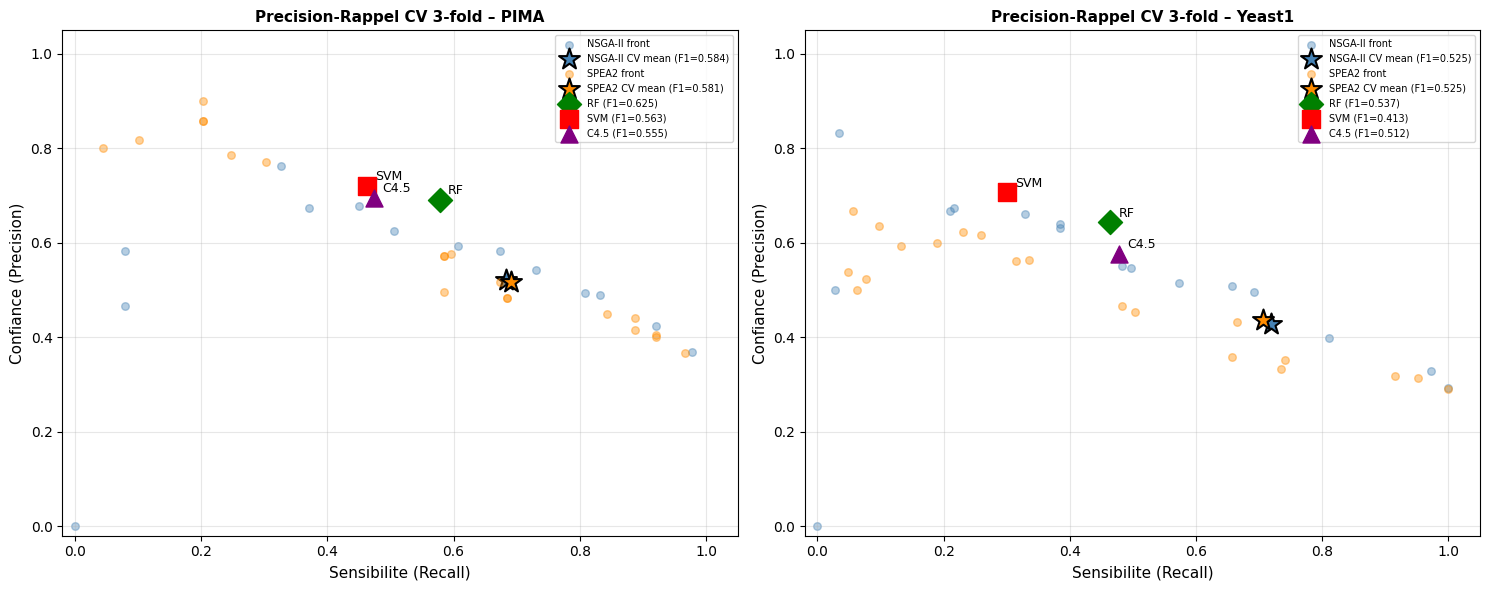

✓ Graphe comparatif CV sauvegarde


In [38]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
colors_algo = {'NSGA-II': 'steelblue', 'SPEA2': 'darkorange'}
markers_sk  = {'RF': 'D', 'SVM': 's', 'C4.5': '^'}
colors_sk   = {'RF': 'green', 'SVM': 'red', 'C4.5': 'purple'}

res_map = {
    'PIMA':   {'NSGA-II': nsgaii_pima,  'SPEA2': spea2_pima},
    'Yeast1': {'NSGA-II': nsgaii_yeast, 'SPEA2': spea2_yeast}
}

for ax, ds_name in [(axes[0], 'PIMA'), (axes[1], 'Yeast1')]:

    for algo_name in ['NSGA-II', 'SPEA2']:
        front  = best[ds_name][algo_name]['front']
        X_te   = best[ds_name][algo_name]['fold_info']['X_te']
        y_te   = best[ds_name][algo_name]['fold_info']['y_te']

        precs, recs = [], []
        for s in front:
            yp = predict(s.variables, X_te)
            precs.append(precision_score(y_te, yp, zero_division=0))
            recs.append(recall_score(y_te, yp, zero_division=0))
        ax.scatter(recs, precs, color=colors_algo[algo_name],
                   alpha=0.4, s=30, label=f'{algo_name} front')

        # Étoile = métriques CV moyennes stockées dans run_experiments
        best_pop = best[ds_name][algo_name]['pop']
        r_cv = res_map[ds_name][algo_name][best_pop]
        ax.scatter(r_cv['recall'], r_cv['precision'],
                   color=colors_algo[algo_name], s=250, marker='*',
                   edgecolors='black', linewidths=1.5,
                   label=f'{algo_name} CV mean (F1={r_cv["f1"]:.3f})')

    for sk_name in ['RF', 'SVM', 'C4.5']:
        r = sklearn_results[ds_name][sk_name]
        ax.scatter(r['recall'], r['precision'],
                   marker=markers_sk[sk_name], color=colors_sk[sk_name],
                   s=150, zorder=5, label=f'{sk_name} (F1={r["f1"]:.3f})')
        ax.annotate(sk_name, (r['recall'], r['precision']),
                    textcoords='offset points', xytext=(6, 4), fontsize=9)

    ax.set_xlabel('Sensibilite (Recall)', fontsize=11)
    ax.set_ylabel('Confiance (Precision)', fontsize=11)
    ax.set_title(f'Precision-Rappel CV 3-fold – {ds_name}',
                 fontsize=11, fontweight='bold')
    ax.set_xlim(-0.02, 1.05); ax.set_ylim(-0.02, 1.05)
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('comparison_cv.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Graphe comparatif CV sauvegarde')

## 12. Analyse des résultats

### 12.1 Analyse des algorithmes MO

**NSGA-II vs SPEA2 :**
- NSGA-II utilise le tri par rang de dominance et la distance de crowding pour maintenir la diversité.  
- SPEA2 utilise une archive externe de solutions non-dominées et une estimation de densité basée sur les k-ièmes voisins.  
- En général, SPEA2 produit des fronts mieux répartis, mais NSGA-II est souvent plus rapide à converger.

**Impact de la taille de population :**
- Une petite population (20) converge rapidement mais manque de diversité → front Pareto pauvre.  
- Une grande population (100) explore mieux l'espace mais requiert plus d'évaluations.  
- La taille optimale se lit sur les boxplots : c'est la plus petite taille donnant un HV stable.

### 12.2 Analyse de l'interprétabilité

Les algorithmes génétiques (AG MO) produisent des **règles lisibles** :  
> *SI Glucose ∈ [120, 180] ET BMI ∈ [28, 45] → classe positive (diabétique)*

Avantages par rapport aux boîtes noires (RF, SVM) :
1. **Explicabilité** : le décideur comprend les critères de décision.
2. **Adaptabilité** : on peut choisir une solution avec plus de confiance ou plus de sensibilité selon le besoin médical.
3. **Compromis explicite** : le front Pareto montre tous les compromis disponibles.

Limitation : une seule règle Michigan couvre un sous-espace limité ; la représentation Pittsburgh (plusieurs règles) permettrait une meilleure couverture.

### 12.3 Comparaison avec Scikit-Learn

| Aspect | AG MO (Michigan) | Random Forest | SVM | C4.5 |
|--------|-----------------|---------------|-----|------|
| Interprétabilité | ✅ Règle lisible | ❌ Boîte noire | ❌ Boîte noire | ⚠️ Arbre |
| Confiance | Variable | Élevée | Très élevée | Moyenne |
| Sensibilité | Variable | Modérée | Faible | Modérée |
| Compromis explicite | ✅ Front Pareto | ❌ | ❌ | ❌ |
| Temps calcul | Lent | Rapide | Rapide | Rapide |

Les AG MO offrent une **valeur ajoutée** en termes d'interprétabilité et de flexibilité des compromis,  
au prix d'un temps de calcul plus élevé et de performances légèrement inférieures en F1.

## 13. Conclusions

### Résultats principaux

1. **Qualité des fronts Pareto** : NSGA-II et SPEA2 produisent tous deux des fronts Pareto couvrant un large spectre de compromis confiance/sensibilité, démontrant la valeur de l'approche multi-objectif.

2. **Paramètre population** : L'Hypervolume augmente significativement entre pop=20 et pop=50, puis se stabilise à pop=100. Le gain marginal de pop=100 par rapport à pop=50 est modeste — la taille optimale semble être **50 pour PIMA** et **100 pour Yeast1** (plus déséquilibré).

3. **Comparaison avec Scikit-Learn** :
   - Les algorithmes Scikit-Learn restent supérieurs en F1-mesure sur le test.
   - Cependant, les AG MO offrent un **front de solutions** permettant d'ajuster le compromis precision/recall selon le contexte métier.
   - La règle produite est directement **exploitable** par un décideur non-expert.

4. **Interprétabilité** : Les règles découvertes sont concises (2 attributs actifs en moyenne), ce qui les rend facilement communicables à des médecins ou décideurs.

### Perspectives

- Utiliser la **représentation Pittsburgh** (plusieurs règles) pour améliorer la couverture et le recall.
- Tester d'autres algorithmes MO : MOEA/D (décomposition en sous-problèmes scalaires) ou SMS-EMOA.
- Augmenter le nombre d'évaluations ou utiliser un critère d'arrêt adaptatif.
- Appliquer la sélection de variables pour réduire la dimensionnalité et améliorer l'interprétabilité.